# Duke Experiment: Ablation Study + Full Baseline Comparison

**Scene:** Duke — single transmitter, same zone as motivating example  
**Frequency:** 3.5 GHz

**Part 1 — Ablation:** Vary `num_sample_points` across gradient baselines to characterize the trade-off between:
- Convergence speed (iterations to threshold)
- Loss curve smoothness / gradient variance
- Total wall-clock runtime

**Part 2 — Full comparison:** Run all 7 baselines at the best sample count identified above.

In [1]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
SCENE_XML_PATH = "../scene/scenes/Duke/scene.xml"
CARRIER_HZ     = 3.5e9

# Transmitter (same building and zone as motivating_example)
TX_NAME        = "gnb"
TX_BUILDING_ID = 33
TX_HEIGHT_M    = 7.0

# ── ZONE CONFIGURATION ──────────────────────────────────────────────────────
# Coordinates are scene-local meters. Run the visualization cell to verify.
ZONE_CENTER   = [40.0, 200.0]
ZONE_WIDTH_M  = 200.0
ZONE_HEIGHT_M = 200.0

MAP_CONFIG = {
    'center':        [0.0, 0.0, 0.0],
    'size':          [1400, 1400],
    'cell_size':     (0.5, 0.5),
    'ground_height': 0.0,
}

# Experiment
NOISE_POWER   = 1e-10
JITTER_SEED   = 42
JITTER_MAG    = 1e-4          # Degrees — convergence tolerance
NUM_ITERATIONS = 50           # Gradient optimizer iterations

# Ablation (PathSolver variants only — sweeps num_sample_points)
SAMPLE_COUNTS  = []
GRAD_BASELINES = ["grad_full_rejection", "grad_full_triangulated", "grad_proportional"]

# Full comparison
ALL_BASELINES  = [
    "grad_full_rejection", "grad_full_triangulated", "grad_proportional",
    "radiomap_gradient",
    "random_search", "pso", "coordinate_descent", "uma_naive",
]
OUTPUT_PATH = "../scripts/report/duke_experiment_results.json"

In [2]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
import mitsuba as mi

try:
    import sionna.rt
except ImportError:
    os.system("pip install sionna-rt")
    import sionna.rt

from sionna.rt import load_scene, AntennaArray
from sionna.rt.antenna_pattern import antenna_pattern_registry

from scene_parser import extract_building_info
from tx_placement import TxPlacement
from boresight_pathsolver import create_zone_mask
from angle_utils import compute_initial_angles_from_position, azimuth_elevation_to_yaw_pitch
from multi_tx_optimizer import TxConfig
from experiment_runner import (
    ExperimentConfig, run_experiment_suite,
    compare_all_results, plot_cdf, plot_loss_curves, plot_metric_bars,
    plot_zone_overview,
)

scene = load_scene(SCENE_XML_PATH)
scene.frequency = CARRIER_HZ

single_el = np.array([[0.0, 0.0, 0.0]])
scene.tx_array = AntennaArray(
    antenna_pattern=antenna_pattern_registry.get("tr38901")(polarization="V"),
    normalized_positions=single_el.T,
)
scene.rx_array = AntennaArray(
    antenna_pattern=antenna_pattern_registry.get("iso")(polarization="V"),
    normalized_positions=single_el.T,
)
for rm in scene.radio_materials.values():
    rm.scattering_coefficient = 0.4

building_info = extract_building_info(SCENE_XML_PATH, verbose=False)
print(f"Scene loaded  |  {CARRIER_HZ/1e9:.1f} GHz")

2026-04-13 10:23:02 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
Scene loaded  |  3.5 GHz


In [3]:
# ── ZONE MASK ────────────────────────────────────────────────────────────────
zone_params = {'center': ZONE_CENTER, 'width': ZONE_WIDTH_M, 'height': ZONE_HEIGHT_M}

zone_mask, look_at_pos, zone_stats = create_zone_mask(
    map_config=MAP_CONFIG,
    zone_type='box',
    zone_params=zone_params,
    target_height=1.5,
    scene_xml_path=SCENE_XML_PATH,
    exclude_buildings=True,
)
zone_masks = {TX_NAME: zone_mask}
print(f"Zone cells: {zone_stats['num_cells']}  |  centroid: {zone_stats['centroid_xy']}")

Zone cells: 117246  |  centroid: [41.890299029391194, 210.93106801084897]


In [4]:
# ── TX PLACEMENT ─────────────────────────────────────────────────────────────
tx_placer = TxPlacement(scene, TX_NAME, SCENE_XML_PATH, TX_BUILDING_ID, offset=TX_HEIGHT_M)
tx_placer.set_rooftop_center()

tx = scene.get(TX_NAME)
tx_pos = tx.position.numpy().flatten().tolist()
print(f"TX at ({tx_pos[0]:.2f}, {tx_pos[1]:.2f}, {tx_pos[2]:.2f})")

TX at (-242.62, 265.64, 28.00)


In [5]:
# ── INITIAL JITTER ───────────────────────────────────────────────────────────
# Same fixed jitter across all ablation runs for fair comparison.
base_az, base_el = compute_initial_angles_from_position(tx_pos, zone_stats["look_at_xyz"])

rng = np.random.default_rng(JITTER_SEED)
initial_az = base_az + float(rng.uniform(-JITTER_MAG, JITTER_MAG))
initial_el = base_el + float(rng.uniform(-JITTER_MAG, JITTER_MAG))

yaw_r, pitch_r = azimuth_elevation_to_yaw_pitch(initial_az, initial_el)
tx.orientation = mi.Point3f(float(yaw_r), float(pitch_r), 0.0)

# Store initial state for restoration between ablation runs
_init_pos_list = tx_pos[:]
_init_yaw, _init_pitch = yaw_r, pitch_r

print(f"Initial Az = {initial_az:.6f}°,  El = {initial_el:.6f}°")

Tx Position: [-242.62303161621094, 265.643798828125, 28.0]
look_at_position: [40.0, 200.0, 1.5]
Initial Az = 346.924027°,  El = -5.218542°


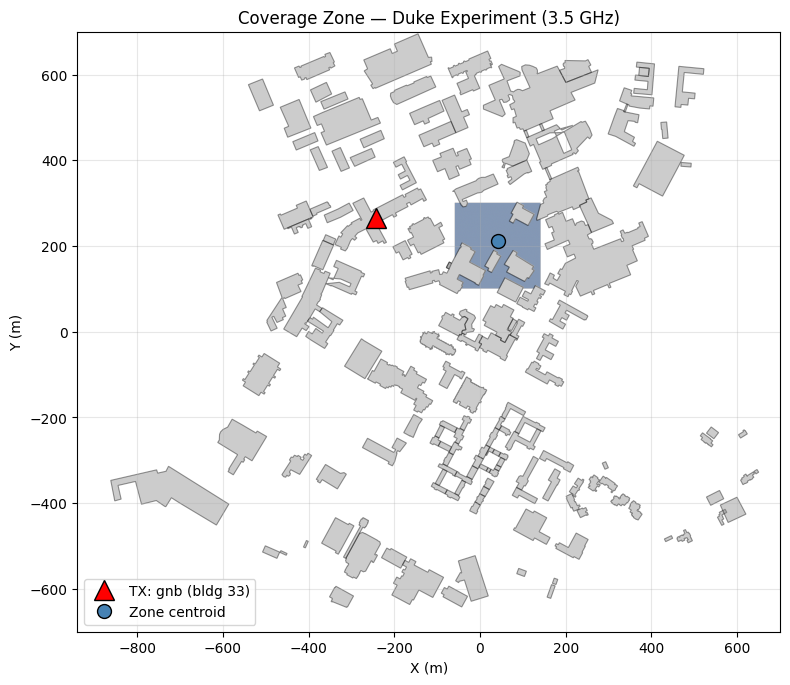

In [6]:
# ── ZONE VISUALIZATION ───────────────────────────────────────────────────────
zone_entries = [
    dict(mask=zone_mask, cmap='Blues', color='steelblue',
         tx_pos=tx_pos, tx_name=TX_NAME, building_id=TX_BUILDING_ID,
         centroid_xy=zone_stats['centroid_xy'], zone_label='Zone centroid',
         marker='^', show_arrow=False),
]
plot_zone_overview(
    building_info, MAP_CONFIG, zone_entries,
    title='Coverage Zone \u2014 Duke Experiment (3.5 GHz)',
    figsize=(8, 8),
)

## Part 1: Sample Count Ablation

Runs the three gradient baselines at each sample count in `SAMPLE_COUNTS`.
Results are stored in `ablation_results[n]` for plotting.

In [ ]:
# ── CONVERGENCE HELPER ───────────────────────────────────────────────────────
def check_convergence(suite_output, baseline_id, tx_name=None, tol=1e-4):
    """Report convergence status for a baseline.

    Priority:
      1. If the optimizer fired early stopping, report that directly.
      2. Otherwise, inspect the loss history tail for residual oscillation.
    """
    entry = suite_output["results"].get(baseline_id, {})
    opt   = entry.get("optimizer_result")
    if not isinstance(opt, dict):
        return {"status": "error"}

    joint          = opt.get("joint", {})
    converged_iter = joint.get("converged_iter")
    loss_history   = joint.get("loss_history", [])
    n_iters        = len(loss_history)

    # 1. Early stopping recorded by the optimizer
    if converged_iter is not None:
        return {"status": "converged (early stop)", "iteration": converged_iter,
                "of": n_iters}

    # 2. Single-evaluation baselines
    if n_iters <= 1:
        return {"status": "single evaluation"}

    # 3. Ran to max iterations — characterise the loss tail
    window = min(10, n_iters)
    recent = loss_history[-window:]
    deltas = [recent[k + 1] - recent[k] for k in range(len(recent) - 1)]
    if deltas:
        n_flips    = sum(1 for k in range(len(deltas) - 1)
                         if deltas[k] * deltas[k + 1] < 0)
        net_change = abs(recent[-1] - recent[0])
        return {
            "status":          "ran to max iterations",
            "iterations":      n_iters,
            "tail_flips":      n_flips,
            "tail_net_Δloss":  round(net_change, 5),
        }

    return {"status": "ran to max iterations", "iterations": n_iters}

In [8]:
# ── ABLATION LOOP ────────────────────────────────────────────────────────────
ablation_results = {}

for n in SAMPLE_COUNTS:
    print(f"\n{'='*60}")
    print(f"  num_sample_points = {n}")
    print(f"{'='*60}")

    # Restore TX to jittered starting state before each suite call
    tx.position    = mi.Point3f(*_init_pos_list)
    tx.orientation = mi.Point3f(float(_init_yaw), float(_init_pitch), 0.0)

    tx_cfg_n = TxConfig(
        name=TX_NAME,
        building_id=TX_BUILDING_ID,
        zone_params=zone_params,
        tx_height_offset=TX_HEIGHT_M,
        num_sample_points=n,
    )
    exp_n = ExperimentConfig(
        baselines=GRAD_BASELINES,
        noise_power=NOISE_POWER,
        num_iterations=NUM_ITERATIONS,
        verbose=True,
    )
    ablation_results[n] = run_experiment_suite(
        scene=scene,
        tx_configs=[tx_cfg_n],
        map_config=MAP_CONFIG,
        scene_xml_path=SCENE_XML_PATH,
        zone_masks=zone_masks,
        exp_config=exp_n,
    )
    elapsed = {b: ablation_results[n]["results"][b]["elapsed_s"] for b in GRAD_BASELINES}
    print(f"  Elapsed: { {b: f'{v:.1f}s' for b, v in elapsed.items()} }")

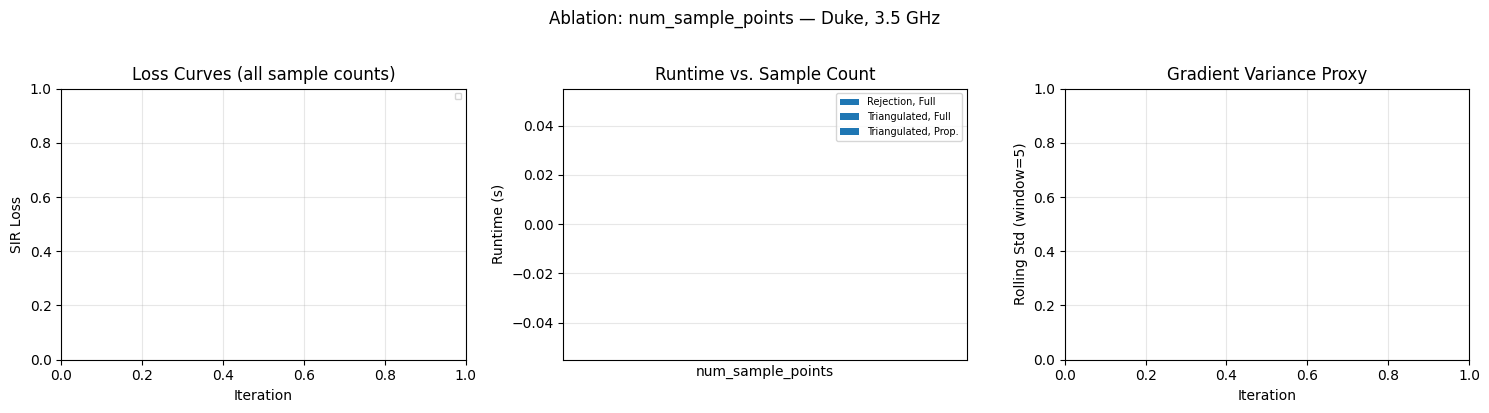

In [9]:
# ── ABLATION PLOTS ───────────────────────────────────────────────────────────
# Colors match experiment_runner.py palette
_colors = {
    "grad_full_rejection":    "#1f77b4",
    "grad_full_triangulated": "#ff7f0e",
    "grad_proportional":      "#2ca02c",
}
_labels = {
    "grad_full_rejection":    "Rejection, Full",
    "grad_full_triangulated": "Triangulated, Full",
    "grad_proportional":      "Triangulated, Prop.",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Loss curves for each sample count (one subplot per baseline would be busy;
#          show all baselines at best_n — after selecting it below)
ax1 = axes[0]
for n in SAMPLE_COUNTS:
    sr = ablation_results[n]
    for bid in GRAD_BASELINES:
        loss = sr["results"][bid].get("optimizer_result", {}).get("joint", {}).get("loss_history", [])
        if loss:
            ax1.plot(range(1, len(loss)+1), loss,
                     color=_colors[bid], alpha=0.4 + 0.15 * SAMPLE_COUNTS.index(n),
                     label=f"{_labels[bid]} n={n}" if SAMPLE_COUNTS.index(n) == len(SAMPLE_COUNTS)//2 else "_")
ax1.set_xlabel("Iteration"); ax1.set_ylabel("SIR Loss")
ax1.set_title("Loss Curves (all sample counts)")
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=6)

# Panel 2: Total runtime vs sample count
ax2 = axes[1]
x = np.arange(len(SAMPLE_COUNTS))
w = 0.25
for i, bid in enumerate(GRAD_BASELINES):
    runtimes = [ablation_results[n]["results"][bid]["elapsed_s"] for n in SAMPLE_COUNTS]
    ax2.bar(x + i*w, runtimes, width=w, color=_colors[bid], label=_labels[bid])
ax2.set_xticks(x + w)
ax2.set_xticklabels([str(n) for n in SAMPLE_COUNTS])
ax2.set_xlabel("num_sample_points"); ax2.set_ylabel("Runtime (s)")
ax2.set_title("Runtime vs. Sample Count")
ax2.legend(fontsize=7); ax2.grid(True, axis='y', alpha=0.3)

# Panel 3: Gradient variance proxy — rolling std of loss_history
ax3 = axes[2]
WIN = 5
for n in SAMPLE_COUNTS:
    sr = ablation_results[n]
    for bid in GRAD_BASELINES:
        loss = sr["results"][bid].get("optimizer_result", {}).get("joint", {}).get("loss_history", [])
        if len(loss) >= WIN:
            rolling_std = [np.std(loss[max(0,i-WIN):i+1]) for i in range(len(loss))]
            ax3.plot(range(1, len(rolling_std)+1), rolling_std,
                     color=_colors[bid], alpha=0.4 + 0.15 * SAMPLE_COUNTS.index(n))
ax3.set_xlabel("Iteration"); ax3.set_ylabel(f"Rolling Std (window={WIN})")
ax3.set_title("Gradient Variance Proxy")
ax3.grid(True, alpha=0.3)

plt.suptitle("Ablation: num_sample_points — Duke, 3.5 GHz", y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# ── CONVERGENCE TABLE ────────────────────────────────────────────────────────
#rows = []
#for n in SAMPLE_COUNTS:
#    row = {"num_samples": n}
#    for bid in GRAD_BASELINES:
#        conv = check_convergence(ablation_results[n], bid, TX_NAME, tol=JITTER_MAG)
#        row[bid] = f"iter {conv['iteration']}" if conv["status"] == "converged" else conv["status"]
#    rows.append(row)

#conv_df = pd.DataFrame(rows).set_index("num_samples")
#conv_df.columns = [_labels[b] for b in GRAD_BASELINES]
#print("\nConvergence Table (tol = 1e-4 deg):")
#print(conv_df.to_string())

In [11]:
# ── SELECT BEST SAMPLE COUNT ─────────────────────────────────────────────────
# Review the ablation plots above, then set best_n here.
best_n = 128   # ← adjust after reviewing plots

## Part 2: Full Baseline Comparison

Runs all 7 baselines at `best_n` sample points.

In [12]:
# ── FULL COMPARISON RUN ──────────────────────────────────────────────────────
# Restore TX to jittered starting state
tx.position    = mi.Point3f(*_init_pos_list)
tx.orientation = mi.Point3f(float(_init_yaw), float(_init_pitch), 0.0)

tx_config_full = TxConfig(
    name=TX_NAME,
    building_id=TX_BUILDING_ID,
    zone_params=zone_params,
    tx_height_offset=TX_HEIGHT_M,
    num_sample_points=best_n,
)
exp_config_full = ExperimentConfig(
    baselines=ALL_BASELINES,
    noise_power=NOISE_POWER,
    num_iterations=NUM_ITERATIONS,
    output_path=OUTPUT_PATH,
    coarse_az_steps=24,
    rs_lds="Uniform",
    rs_seed=42,
)
suite_output = run_experiment_suite(
    scene=scene,
    tx_configs=[tx_config_full],
    map_config=MAP_CONFIG,
    scene_xml_path=SCENE_XML_PATH,
    zone_masks=zone_masks,
    exp_config=exp_config_full,
)


EXPERIMENT SUITE  —  8 baseline(s)  |  1 TX(s)
Initial angles:
  gnb: Az=346.9°  El=-5.2°  pos=(-242.6, 265.6, 28.0)


######################################################################
  BASELINE: grad_full_rejection
######################################################################

MULTI-TX SIR OPTIMIZATION  (1 transmitters)
Pre-created 128 receivers ([128] per zone)
  Iter   1/50  loss=24.3831  (2.2s)
  Iter   2/50  loss=24.0982  (2.1s)
  Iter   3/50  loss=23.7417  (2.1s)
  Iter   4/50  loss=23.7763  (2.1s)
  Iter   5/50  loss=23.6331  (2.1s)
  Iter   6/50  loss=23.4100  (2.1s)
  Iter   7/50  loss=23.5465  (2.1s)
  Iter   8/50  loss=23.0959  (1.8s)
  Iter   9/50  loss=22.9405  (2.1s)
  Iter  10/50  loss=23.2059  (2.1s)
  Iter  11/50  loss=22.8680  (2.1s)
  Iter  12/50  loss=22.6987  (2.1s)
  Iter  13/50  loss=22.4465  (2.1s)
  Iter  14/50  loss=22.5686  (2.1s)
  Iter  15/50  loss=22.2923  (2.2s)
  Iter  16/50  loss=22.1119  (1.7s)
  Iter  17/50  loss=22.2996  (1.9s)
  Iter

nanobind: implicit conversion from type 'drjit.cuda.ad.TensorXf' to type 'drjit.cuda.ad.Float' failed!


  [ERROR] Optimizer failed for 'radiomap_gradient': mitsuba.Point3f.__init__(): Item assignment failed.

  [radiomap_gradient] done — 0.8s  status=FAILED

######################################################################
  BASELINE: random_search
######################################################################

RANDOM SEARCH BASELINE  (200 candidates, 1 TX)
  [   1/200]  loss=21.7523  best=21.7523
  [  21/200]  loss=26.7212  best=5.1501
  [  41/200]  loss=18.7452  best=5.1501
  [  61/200]  loss=13.1781  best=5.1501
  [  81/200]  loss=20.7391  best=5.1501
  [ 101/200]  loss=26.3303  best=2.2535
  [ 121/200]  loss=24.1554  best=0.9458
  [ 141/200]  loss=19.3357  best=0.9458
  [ 161/200]  loss=22.5526  best=0.9458
  [ 181/200]  loss=22.9391  best=0.9458
  [ 200/200]  loss=44.0086  best=0.9458

Best loss: 0.9458  (26.5s)
  gnb: Az=331.5°  El=-33.8°  pos=(-132.0, 275.1)


BEFORE / AFTER COMPARISON
  gnb:
    Initial:   Az=346.9°, El=-5.2°, pos=(-242.6, 265.6)
    Optimised: Az=33

In [13]:
# ── CONVERGENCE + RESULTS TABLE ──────────────────────────────────────────────
print(f"\n{'─'*55}")
print(f"  Convergence Analysis  (tol = {JITTER_MAG:.0e} deg, n = {best_n})")
print(f"{'─'*55}")
for bid in ALL_BASELINES:
    conv = check_convergence(suite_output, bid, TX_NAME, tol=JITTER_MAG)
    print(f"  {bid:<30s}  {conv}")

df = compare_all_results(suite_output)


───────────────────────────────────────────────────────
  Convergence Analysis  (tol = 1e-04 deg, n = 128)
───────────────────────────────────────────────────────
  grad_full_rejection             {'status': 'no convergence', 'iterations': 50}
  grad_full_triangulated          {'status': 'no convergence', 'iterations': 50}
  grad_proportional               {'status': 'no convergence', 'iterations': 50}
  radiomap_gradient               {'status': 'error'}
  random_search                   {'status': 'displaced', 'Δaz_deg': np.float64(15.4449), 'Δel_deg': np.float64(28.5826)}
  pso                             {'status': 'displaced', 'Δaz_deg': np.float64(11.6541), 'Δel_deg': np.float64(0.9016)}
  coordinate_descent              {'status': 'displaced', 'Δaz_deg': np.float64(5.8714), 'Δel_deg': np.float64(4.2551)}
  uma_naive                       {'status': 'displaced', 'Δaz_deg': np.float64(2.1901), 'Δel_deg': np.float64(0.7815)}

RESULTS SUMMARY  (OPTIMIZED)  —  TX: all (avg)
        

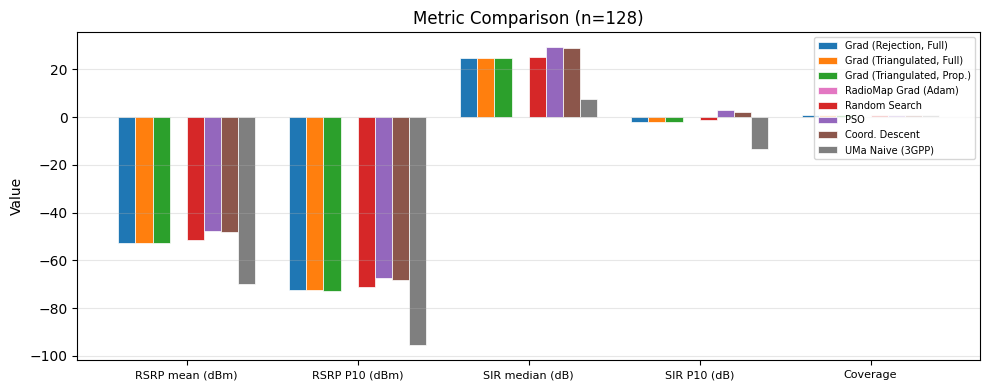

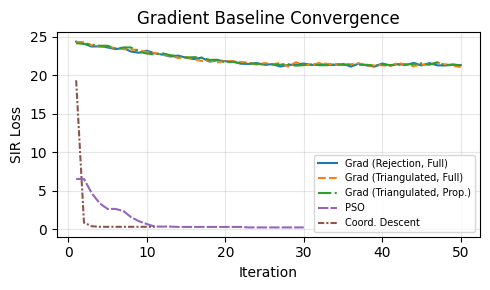

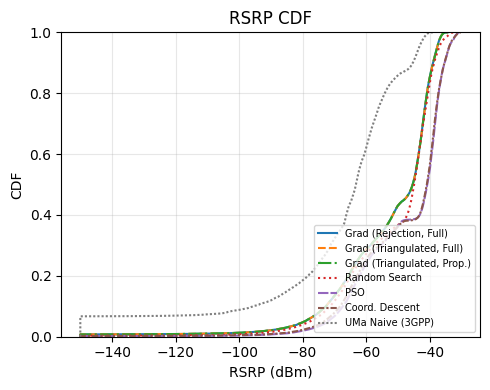

In [14]:
# ── VISUALIZATION ────────────────────────────────────────────────────────────
plot_metric_bars(
    suite_output,
    metrics=("rsrp_mean_dbm", "rsrp_p10_dbm", "sir_median_db", "sir_p10_db", "coverage_fraction"),
)
plt.title(f"Metric Comparison (n={best_n})")
plt.tight_layout()
plt.show()

plot_loss_curves(
    suite_output,
    baselines=[b for b in ALL_BASELINES if b != "random_search"],
)
plt.title("Gradient Baseline Convergence")
plt.tight_layout()
plt.show()

plot_cdf(suite_output, metric="rsrp_values_dbm")
plt.title("RSRP CDF")
plt.tight_layout()
plt.show()